# Camera undistortion (FOR BEV)

- For the MIT Han Lab BEVFusion codebase, the camera view transform is written as if the camera follows a pinhole projection with a 3×3 intrinsic matrix. Raw fisheye-distorted ZOD images are not what this implementation is set up for.
- The intrinsics passed into BEVFusion should be the intrinsics of that rectified image.
- after you undistort the raw fisheye image, the old raw-camera intrinsic matrix K is no longer the correct projection matrix for the new image.
- we want: (raw image,K,D)→undistort→(rectified image,new_K)→BEVFusion


- original ZOD front image: 3848 × 2168
- resized training image: 1248 × 704
SO WE NEED: Kraw --> undistort --> Krectified --> resize --> Kfinal. (focal length and principal point change with image resolution so must rescale) ---> feed Kfinal to BEV. 

In [1]:
# Imports + load parquet row + pick one frame/image

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
#for undistortion
import cv2

# ZOD SDK
from zod.data_classes.info import Information
from zod.data_classes.frame import ZodFrame
from zod.constants import Camera, Lidar

# Parquet index (note: file is ZODmoe..., not ODmoe...)
INDEX_PATH = Path("/home/edgelab/multimodal-MoE/outputs/index/ZODmoe_frames_with_xyxy_bboxes_and_solar_bins.parquet")
df = pd.read_parquet(INDEX_PATH)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# Pick a row with pedestrians if available, else first row.
if "ped_present" in df.columns and (df["ped_present"] == 1).any():
    row = df[df["ped_present"] == 1].iloc[5000]
else:
    row = df.iloc[0]

frame_id = str(row["frame_id"])
image_path = Path(row["image_path"])  # original non-resized path from parquet
frame_dir = image_path.parent.parent   # .../<frame_id>/camera_front_dnat/<img>.jpg -> .../<frame_id>

print("Selected frame_id:", frame_id)
print("Original image path:", image_path)
print("Frame dir:", frame_dir)

Rows: 99999
Columns: ['frame_id', 'time', 'image_path', 'resized_image_path', 'orig_w', 'orig_h', 'new_w', 'new_h', 'sx', 'sy', 'scraped_weather', 'time_of_day', 'solar_angle_elevation', 'country_code', 'road_type', 'road_condition', 'ped_count_clear', 'ped_count_unclear', 'ped_occ_none', 'ped_occ_light', 'ped_occ_medium', 'ped_occ_heavy', 'ped_occ_veryheavy', 'ped_occ_missing', 'ped_occ_unknown', 'ped_uuid', 'ped_unclear_list', 'ped_occlusion_list', 'ped_points_xy_resized', 'ped_bin_4', 'ped_present', 'xyxy_bboxes', 'solar_context_bin']
Selected frame_id: 060350
Original image path: /home/edgelab/zod_dino_data/train2017/060350/camera_front_dnat/060350_india_2020-11-16T11:40:58.224750Z.jpg
Frame dir: /home/edgelab/zod_dino_data/train2017/060350


In [2]:
# Build zod_frame from raw folder

def make_zodframe_from_raw(frame_dir: Path) -> ZodFrame:
    """
    Build ZodFrame from raw single-frame directory layout.
    This fixes relative paths in info.json to be frame-local.
    """
    info_dict = json.loads((frame_dir / "info.json").read_text())
    fid = info_dict.get("id", frame_dir.name)
    prefix = f"single_frames/{fid}/"

    def fix_path(p):
        if p is None:
            return None
        if p.startswith(prefix):
            return p[len(prefix):]
        if p.startswith("single_frames/"):
            return p.split("/", 2)[-1]
        return p

    # top-level paths
    for k in ["calibration_path", "ego_motion_path", "metadata_path", "oxts_path", "vehicle_data_path"]:
        if info_dict.get(k) is not None:
            info_dict[k] = fix_path(info_dict[k])

    # annotation paths
    for ann in info_dict.get("annotations", {}).values():
        if ann.get("filepath") is not None:
            ann["filepath"] = fix_path(ann["filepath"])

    # camera frame paths
    for arr in info_dict.get("camera_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    # lidar frame paths
    for arr in info_dict.get("lidar_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    info = Information.from_dict(info_dict)
    info.convert_paths_to_absolute(str(frame_dir))
    return ZodFrame(info)

zod_frame = make_zodframe_from_raw(frame_dir)
calib = zod_frame.calibration

print("zod_frame id:", zod_frame.info.id)
print("Camera intrinsics shape:", calib.cameras[Camera.FRONT].intrinsics.shape)
print("Camera distortion:", calib.cameras[Camera.FRONT].distortion)
print("K:" , calib.cameras[Camera.FRONT].intrinsics)
print("camera extrinsics:" , calib.cameras[Camera.FRONT].extrinsics)
print("lidar extrinsics:" , calib.lidars[Lidar.VELODYNE].extrinsics)

zod_frame id: 060350
Camera intrinsics shape: (3, 4)
Camera distortion: [-0.00592982 -0.05365763  0.06591502 -0.02476903]
K: [[1.85734965e+03 0.00000000e+00 1.91792462e+03 0.00000000e+00]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]
camera extrinsics: Pose(transform=array([[-2.14329446e-02, -3.70766254e-03,  9.99763413e-01,
         2.01530662e+00],
       [-9.99662599e-01, -1.45975140e-02, -2.14849188e-02,
         4.90213071e-04],
       [ 1.46737192e-02, -9.99886576e-01, -3.39354386e-03,
         1.12506001e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]))
lidar extrinsics: Pose(transform=array([[-2.63011203e-02,  9.99652966e-01,  1.48268749e-03,
         1.06118588e+00],
       [-9.99631595e-01, -2.62905553e-02, -6.74402049e-03,
        -8.38447650e-03],
       [-6.70269941e-03, -1.65951655e-03,  9.99976160e-01,
         1.70625142e+00],
       [ 0.00000000e+

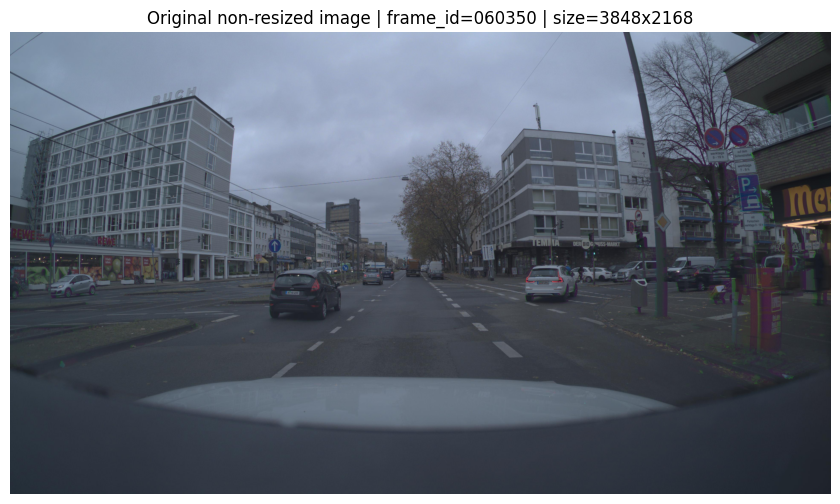

In [3]:
# Load and display ORIGINAL (non-resized) image from parquet path

img_rgb = np.array(Image.open(image_path).convert("RGB"))
h, w = img_rgb.shape[:2]

plt.figure(figsize=(12, 6))
plt.imshow(img_rgb)
plt.title(f"Original non-resized image | frame_id={frame_id} | size={w}x{h}")
plt.axis("off")
plt.show()

https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html (cv2 undistortion using intrinsics matrix and distortion coefficients or undistortion coefficients)

intrinsics K: [[1.85734965e+03 0.00000000e+00 1.91792462e+03]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion D: [[-0.00592982]
 [-0.05365763]
 [ 0.06591502]
 [-0.02476903]]
K:
 [[1.85734965e+03 0.00000000e+00 1.91792462e+03]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
D:
 [[-0.00592982]
 [-0.05365763]
 [ 0.06591502]
 [-0.02476903]]
w, h: 3848 2168
balance: 0.3
new_K: [[1.46751027e+03 0.00000000e+00 1.91068977e+03]
 [0.00000000e+00 1.46751027e+03 1.12323563e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


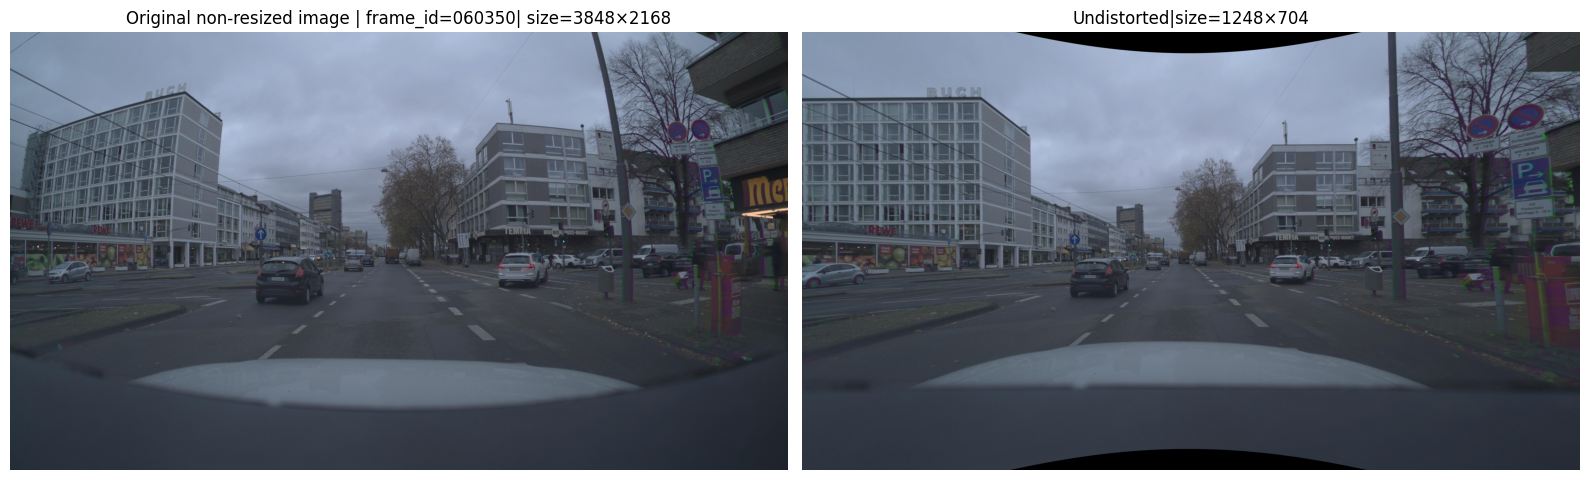

In [5]:
# Undistort using ZOD calibration intrinsics + distortion (Kannala/fisheye style via OpenCV)

cam_calib = calib.cameras[Camera.FRONT]

# ZOD intrinsics are stored as 3x4; OpenCV fisheye expects 3x3.
K = cam_calib.intrinsics[:3, :3].astype(np.float64)
print(f"intrinsics K: {K}")
# D is a 4x1 vector (distortion coefficients)
D = cam_calib.distortion.astype(np.float64).reshape(4, 1)
print(f"distortion D: {D}")

# Build undistortion mapping.
# balance=0.0 => less black border (more crop), balance=1.0 => keep more FoV
# balance controls the focal length of the undistorted image.
#balance = 0  → large focal length (zoomed in, edges cropped, objects appear larger, rectified image uses only central rays)
#balance = 1  → small focal length (zoomed out, almost full FOV, objects appear smaller, rectified image keeps more rays)
# THE QUESTION IS: larger pedestrians vs cleaner labels
balance = 0.3

print("K:\n", K)
print("D:\n", D)
print("w, h:", w, h)
print("balance:", balance)

new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K, D, (w, h), np.eye(3), balance=balance
)
print("new_K:" , new_K)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
)

# Remap image (we remap the pixels to the undistorted image)
# for each pixel: "where should I sample from in the original distorted image?” That produces a rectified image consistent with new_K."
undistorted_rgb = cv2.remap(
    img_rgb, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
)

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original non-resized image | frame_id=060350| size=3848×2168")
axes[0].axis("off")

axes[1].imshow(undistorted_rgb)
axes[1].set_title("Undistorted|size=1248×704")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### TWO IMPORTANT THINGS TO NOTE:
- FOV changes when we undistort, and is determined in part by the "balance" hyperparameter. If we keep balance = 0 we'll crop out some annotations, and must take that into account and filter out pedestrians who are outside of the FOV if we do that. If we set balance=1, we maintain FOV for the most part but pedestrians decrease in size.  
- We must also recompute the LiDAR camera-FoV filter using the final rectified camera model, not the raw one.

In [ ]:
# ============================================================
# Sanity check: project pedestrian 3D boxes onto the
# undistorted + resized image using:
#
#   ZOD SDK transforms  -> camera frame
#   BEV_intrinsics      -> pixel coordinates
#
# This verifies that the final camera geometry is consistent.
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

from zod.constants import Camera
from zod.utils.geometry import transform_points

# ------------------------------------------------------------
# Helper: build cuboid corners from center, dimensions, quaternion
# ------------------------------------------------------------
def make_box_corners_3d(center_xyz, size_lwh, orientation):
    """
    Build the 8 corners of a 3D box in the SAME source frame
    as the provided center.

    Parameters
    ----------
    center_xyz : array-like of shape (3,)
        Box center [x, y, z]
    size_lwh : array-like of shape (3,)
        Box size [length, width, height]
    orientation : Quaternion
        Full 3D box orientation as a quaternion.
        Expected to expose `.rotation_matrix` of shape (3, 3).

    Returns
    -------
    corners : np.ndarray of shape (8, 3)
        8 corners of the cuboid in the same frame as center_xyz
    """
    center_xyz = np.asarray(center_xyz, dtype=np.float64)
    size_lwh = np.asarray(size_lwh, dtype=np.float64)

    cx, cy, cz = center_xyz
    l, w, h = size_lwh

    # Local box corners around the origin before rotation.
    # Convention:
    #   length along local x
    #   width  along local y
    #   height along local z
    x_c = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2], dtype=np.float64)
    y_c = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2], dtype=np.float64)
    z_c = np.array([ h/2,  h/2,  h/2,  h/2, -h/2, -h/2, -h/2, -h/2], dtype=np.float64)

    corners_local = np.stack([x_c, y_c, z_c], axis=1)  # (8, 3)

    # Full 3D rotation from quaternion
    R = np.asarray(orientation.rotation_matrix, dtype=np.float64)  # (3, 3)

    # Rotate then translate into the source frame
    corners_rot = corners_local @ R.T
    corners = corners_rot + np.array([cx, cy, cz], dtype=np.float64)

    return corners


# ------------------------------------------------------------
# Helper: project camera-frame 3D points using final intrinsics
# ------------------------------------------------------------
def project_points_camera_frame_to_pixels(points_cam, K):
    """
    Project 3D points already expressed in CAMERA FRAME
    into image pixels using standard pinhole projection.

    Parameters
    ----------
    points_cam : np.ndarray of shape (N, 3)
        3D points in camera frame
    K : np.ndarray of shape (3, 3)
        Final intrinsics for the undistorted + resized image

    Returns
    -------
    pixels : np.ndarray of shape (N, 2)
        Pixel coordinates
    valid_mask : np.ndarray of shape (N,)
        True for points with positive depth
    """
    x = points_cam[:, 0]
    y = points_cam[:, 1]
    z = points_cam[:, 2]

    valid_mask = z > 1e-6

    u = np.full_like(z, fill_value=np.nan, dtype=np.float64)
    v = np.full_like(z, fill_value=np.nan, dtype=np.float64)

    u[valid_mask] = K[0, 0] * (x[valid_mask] / z[valid_mask]) + K[0, 2]
    v[valid_mask] = K[1, 1] * (y[valid_mask] / z[valid_mask]) + K[1, 2]

    pixels = np.stack([u, v], axis=1)
    return pixels, valid_mask


# ------------------------------------------------------------
# Helper: draw projected cuboid
# ------------------------------------------------------------
def draw_projected_cuboid(image_rgb, pixels, valid_mask, color=(0, 255, 0), thickness=1):
    """
    Draw a 3D cuboid projected into 2D.
    Assumes pixel ordering matches make_box_corners_3d().
    """
    img = image_rgb.copy()

    # If any corner is behind the camera, skip for safety
    if not np.all(valid_mask):
        return img

    pts = np.round(pixels).astype(int)

    # Top face: indices 0,1,2,3
    # Bottom face: indices 4,5,6,7
    top_edges = [(0,1), (1,2), (2,3), (3,0)]
    bottom_edges = [(4,5), (5,6), (6,7), (7,4)]
    side_edges = [(0,4), (1,5), (2,6), (3,7)]

    for i, j in top_edges + bottom_edges + side_edges:
        p1 = tuple(pts[i])
        p2 = tuple(pts[j])
        cv2.line(img, p1, p2, color=color, thickness=thickness)

    return img


# ------------------------------------------------------------
# Helper: draw projected center point
# ------------------------------------------------------------
def draw_projected_center(image_rgb, pixel_xy, color=(255, 0, 0), radius=5):
    img = image_rgb.copy()
    if np.all(np.isfinite(pixel_xy)):
        u, v = np.round(pixel_xy).astype(int)
        h, w = img.shape[:2]
        if 0 <= u < w and 0 <= v < h:
            cv2.circle(img, (u, v), radius, color, -1)
    return img

In [ ]:
def undistort_and_resize(img_rgb, K, D, out_w, out_h, balance):
    h, w = img_rgb.shape[:2]

    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, (w, h), np.eye(3), balance=balance
    )

    map1, map2 = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
    )

    undistorted_rgb = cv2.remap(
        img_rgb, map1, map2,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT
    )

    sx = out_w / w
    sy = out_h / h
    S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], dtype=np.float64)
    BEV_intrinsics = S @ new_K

    resized_undistorted_img = cv2.resize(undistorted_rgb, (out_w, out_h))

    return undistorted_rgb, resized_undistorted_img, new_K, BEV_intrinsics

In [ ]:
undistorted_rgb, resized_undistorted_img, new_K, BEV_intrinsics = undistort_and_resize(
    img_rgb, K, D, 1248, 704, balance=0.3
)
print("BEV_intrinsics (final intrinsics for undistorted + resized image):" , BEV_intrinsics)

BEV_intrinsics (final intrinsics for undistorted + resized image): [[475.94927621   0.         619.68316825]
 [  0.         476.53469967 364.74072247]
 [  0.           0.           1.        ]]


Found 9 pedestrian(s) with 3D annotation in this frame.
T_cam_from_lidar:
[[ 0.99975967  0.00483183  0.02138334  0.03784955]
 [ 0.02139159 -0.00166327 -0.99976979 -0.57745838]
 [-0.00479515  0.99998694 -0.00176623 -0.95567663]
 [ 0.          0.          0.          1.        ]]

Pedestrian 1/9
uuid: 18f1d258-1450-4cd1-8e10-743f14822a68
center_lidar: [ 8.72960687 54.30617889 -0.81362041]
size_lwh: [0.41666667 0.65833333 1.45512667]
orientation quaternion: 0.860 -0.021i -0.033j +0.508k

Pedestrian 2/9
uuid: 2b1e9240-5cf6-416c-91f6-17c5f16eeb84
center_lidar: [11.61263915  7.71075488 -0.48026065]
size_lwh: [0.48810658 0.63124348 1.81617556]
orientation quaternion: 0.966 -0.020i -0.052j +0.253k

Pedestrian 3/9
uuid: 356cd64a-ff5d-490a-ba09-1e838c95a5b0
center_lidar: [10.16429972 10.72036894 -0.67674185]
size_lwh: [0.63400876 0.60674157 1.66008852]
orientation quaternion: -0.601 -0.025i +0.034j +0.798k

Pedestrian 4/9
uuid: 366dab83-ab60-4cbf-8e95-b790cd6e335a
center_lidar: [-36.71974806  45

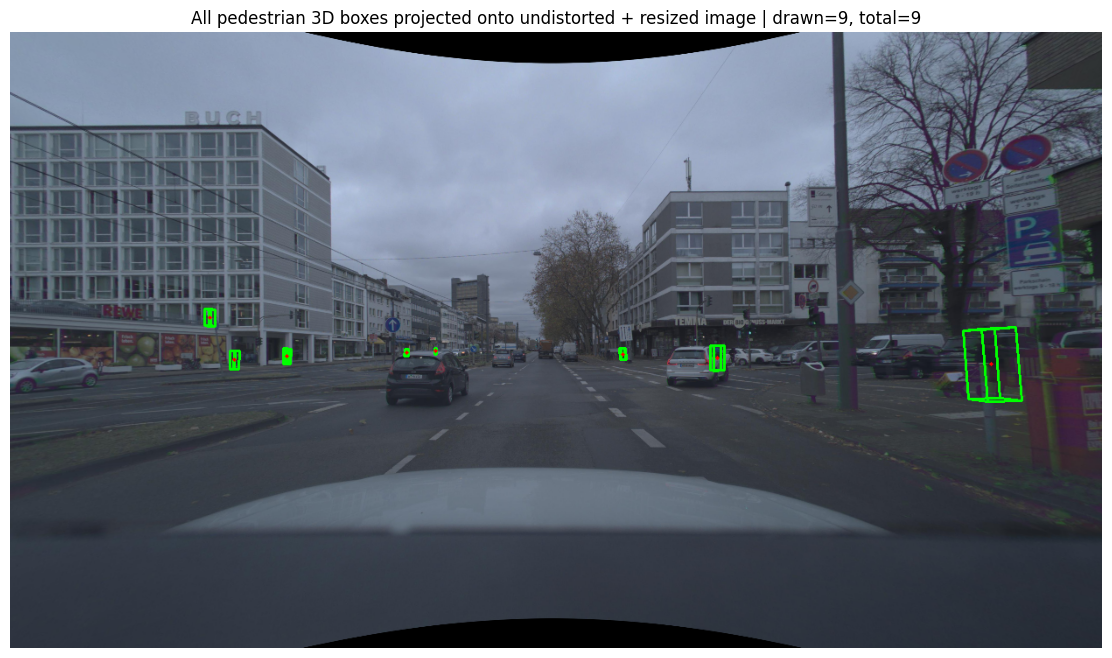

In [ ]:
# ============================================================
# Project ALL pedestrian 3D boxes in this keyframe
# CASE: 3D boxes are in LiDAR frame and orientation is quaternion
# ============================================================

# Assumptions:
# - `zod_frame` is your loaded ZOD frame object
# - `calib` is the frame calibration object
# - `resized_undistorted_img` is the final image
# - `BEV_intrinsics` is the final 3x3 matrix computed above
# - `make_box_corners_3d`, `project_points_camera_frame_to_pixels`,
#   `draw_projected_cuboid`, and `draw_projected_center`
#   have already been defined
# ============================================================


from zod.constants import Camera, Lidar, AnnotationProject
from zod.utils.geometry import transform_points

img_vis = resized_undistorted_img.copy()

# ------------------------------------------------------------
# 1) Get all pedestrian annotations with 3D boxes
# ------------------------------------------------------------
anns = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)

pedestrian_objs = []
for obj in anns:
    # Keep only pedestrians that have 3D geometry
    if obj.name == "Pedestrian" and obj.box3d is not None:
        pedestrian_objs.append(obj)

if len(pedestrian_objs) == 0:
    raise ValueError("No pedestrian with 3D annotation found in this frame.")

print(f"Found {len(pedestrian_objs)} pedestrian(s) with 3D annotation in this frame.")

# ------------------------------------------------------------
# 2) Build transform from LiDAR frame -> camera frame
# ------------------------------------------------------------
# Camera extrinsics are camera -> ego
# LiDAR extrinsics are lidar -> ego
#
# Therefore:
#   T_cam_from_ego   = inverse(T_ego_from_cam)
#   T_cam_from_lidar = T_cam_from_ego @ T_ego_from_lidar
# ------------------------------------------------------------
cam_calib = calib.cameras[Camera.FRONT]
lidar_calib = calib.lidars[Lidar.VELODYNE]

T_ego_from_cam = cam_calib.extrinsics.transform
T_cam_from_ego = np.linalg.inv(T_ego_from_cam)

T_ego_from_lidar = lidar_calib.extrinsics.transform
T_cam_from_lidar = T_cam_from_ego @ T_ego_from_lidar

print("T_cam_from_lidar:")
print(T_cam_from_lidar)

# ------------------------------------------------------------
# 3) Loop over all pedestrian boxes and draw them
# ------------------------------------------------------------
num_drawn = 0
num_skipped_behind_camera = 0

for i, pedestrian_obj in enumerate(pedestrian_objs):
    box3d = pedestrian_obj.box3d

    center_lidar = np.asarray(box3d.center, dtype=np.float64)
    size_lwh = np.asarray(box3d.size, dtype=np.float64)
    orientation = box3d.orientation

    print(f"\nPedestrian {i+1}/{len(pedestrian_objs)}")
    print("uuid:", pedestrian_obj.uuid)
    print("center_lidar:", center_lidar)
    print("size_lwh:", size_lwh)
    print("orientation quaternion:", orientation)

    # --------------------------------------------------------
    # Build 3D box corners in LiDAR frame
    # --------------------------------------------------------
    corners_lidar = make_box_corners_3d(
        center_xyz=center_lidar,
        size_lwh=size_lwh,
        orientation=orientation,
    )

    center_lidar_2d = center_lidar.reshape(1, 3)

    # --------------------------------------------------------
    # Transform LiDAR -> camera
    # --------------------------------------------------------
    corners_cam = transform_points(corners_lidar, T_cam_from_lidar)
    center_cam = transform_points(center_lidar_2d, T_cam_from_lidar)

    # --------------------------------------------------------
    # Project camera-frame points using final intrinsics
    # --------------------------------------------------------
    pixels_corners, valid_mask_corners = project_points_camera_frame_to_pixels(
        corners_cam,
        BEV_intrinsics
    )

    pixels_center, valid_mask_center = project_points_camera_frame_to_pixels(
        center_cam,
        BEV_intrinsics
    )

    # Skip cuboids with any corner behind the camera
    if not np.all(valid_mask_corners):
        num_skipped_behind_camera += 1
        print("Skipped: at least one cuboid corner is behind the camera.")
        continue

    # --------------------------------------------------------
    # Draw cuboid
    # --------------------------------------------------------
    img_vis = draw_projected_cuboid(
        img_vis,
        pixels_corners,
        valid_mask_corners,
        color=(0, 255, 0),
        thickness=2
    )

    # Draw center if valid
    if valid_mask_center[0]:
        img_vis = draw_projected_center(
            img_vis,
            pixels_center[0],
            color=(255, 0, 0),
            radius=2
        )

    num_drawn += 1

# ------------------------------------------------------------
# 4) Summary
# ------------------------------------------------------------
print("\nSummary")
print(f"Total pedestrians with 3D boxes: {len(pedestrian_objs)}")
print(f"Drawn on image: {num_drawn}")
print(f"Skipped because behind camera: {num_skipped_behind_camera}")

# ------------------------------------------------------------
# 5) Display result
# ------------------------------------------------------------
plt.figure(figsize=(16, 8))
plt.imshow(img_vis)
plt.title(
    f"All pedestrian 3D boxes projected onto undistorted + resized image | "
    f"drawn={num_drawn}, total={len(pedestrian_objs)}"
)
plt.axis("off")
plt.show()

In [ ]:
# ------------------------------------------------------------
# Camera extrinsics from calibration
# ------------------------------------------------------------

Extrinsics_ego_from_camera = cam_calib.extrinsics.transform.astype(np.float64)

# Inverse gives camera <- ego
Extrinsics_camera_from_ego = np.linalg.inv(Extrinsics_ego_from_camera)

# ------------------------------------------------------------
# Projection from ego frame to image pixels
#
# pixel = Intrinsics * Extrinsics(camera ← ego) * point_ego
# ------------------------------------------------------------

ego2image = (BEV_intrinsics @ Extrinsics_camera_from_ego[:3, :]).astype(np.float64)

# ------------------------------------------------------------
# Identity augmentation matrices
# ------------------------------------------------------------
# we set these to identity because we are not using any augmentation
# the image is already undistorted and resized
img_aug_matrix = np.eye(4, dtype=np.float64)
fusion_aug_matrix = np.eye(4, dtype=np.float64)

# ------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------
npz_path = Path(f"/home/edgelab/multimodal-MoE/outputs/tmp/{frame_id}_bev_inputs.npz")
np.savez_compressed(
    npz_path,

    frame_id=np.array(frame_id),
    camera_name=np.array("FC"),

    image_h=np.array(resized_undistorted_img.shape[0], dtype=np.int32),
    image_w=np.array(resized_undistorted_img.shape[1], dtype=np.int32),

    # intrinsics
    K_final=BEV_intrinsics.astype(np.float32),

    # camera pose
    camera2ego=Extrinsics_ego_from_camera.astype(np.float32),

    # projection matrix for ego-frame points
    ego2image=ego2image.astype(np.float32),

    # augmentation matrices
    img_aug_matrix=img_aug_matrix.astype(np.float32),
    fusion_aug_matrix=fusion_aug_matrix.astype(np.float32),
)

Found 9 pedestrian(s) with 3D annotation in frame 060350.
T_cam_from_lidar:
[[ 0.99975967  0.00483183  0.02138334  0.03784955]
 [ 0.02139159 -0.00166327 -0.99976979 -0.57745838]
 [-0.00479515  0.99998694 -0.00176623 -0.95567663]
 [ 0.          0.          0.          1.        ]]

T_ego_from_lidar:
[[-2.63011203e-02  9.99652966e-01  1.48268749e-03  1.06118588e+00]
 [-9.99631595e-01 -2.62905553e-02 -6.74402049e-03 -8.38447650e-03]
 [-6.70269941e-03 -1.65951655e-03  9.99976160e-01  1.70625142e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Summary
Total pedestrians with 3D boxes: 9
Kept after final camera-FoV filtering: 8
Rejected outside final image:         1


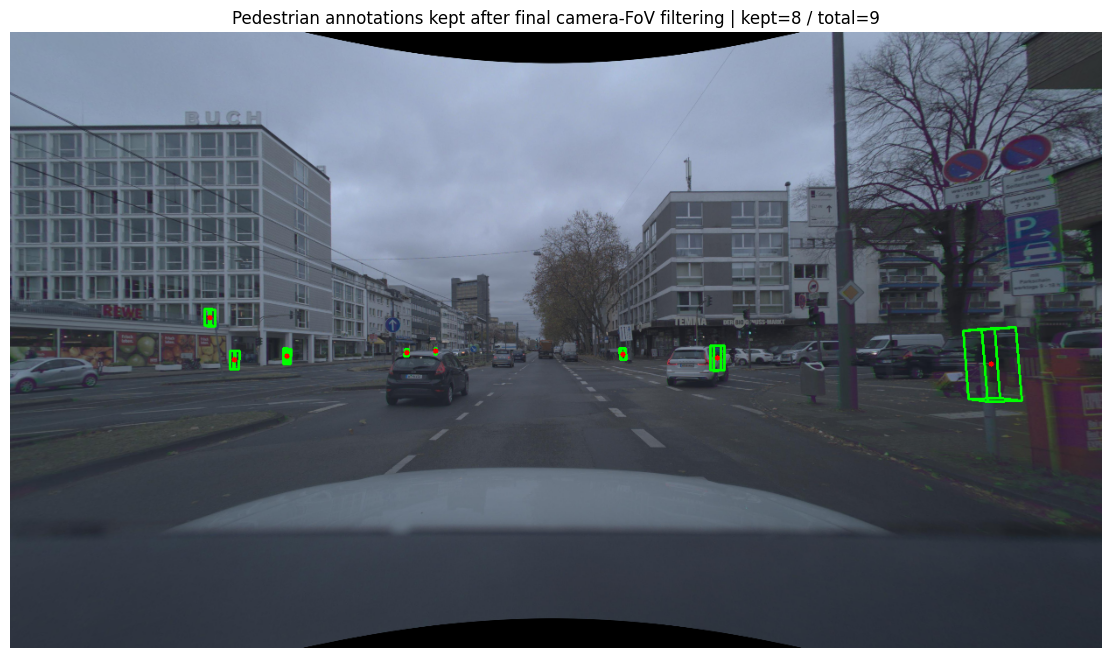


Saved:
- overlay: /home/edgelab/multimodal-MoE/outputs/tmp/060350_pedestrians_filtered_overlay.png
- export : /home/edgelab/multimodal-MoE/outputs/tmp/060350_pedestrians_final_ego.json

Preview of final exported instances:

Instance 1
annotation_uuid: 18f1d258-1450-4cd1-8e10-743f14822a68
class: Pedestrian
box_3d: [55.11771389342382, -10.157027843004279, 0.016453143884290755, 0.41666666666666313, 0.658333333333333, 1.4551266709060542, -0.5285286471495119]
projected_center_uv: [700.12819361059, 367.7119618728076]

Instance 2
annotation_uuid: 356cd64a-ff5d-490a-ba09-1e838c95a5b0
class: Pedestrian
box_3d: [11.50949861705664, -10.44622010756111, 0.1135625751246998, 0.6340087621071058, 0.6067415730337085, 1.660088519480523, 2.8364418511195475]
projected_center_uv: [1121.1038745813803, 379.3906988507922]

Instance 3
annotation_uuid: 366dab83-ab60-4cbf-8e95-b790cd6e335a
class: Pedestrian
box_3d: [47.025427347984774, 35.499832100215365, 3.16039280360294, 0.5677828054298615, 0.6523076923076881,

In [ ]:
# ============================================================
# FINAL CELL:
#
# This cell performs TWO final tasks for pedestrian annotations:
#
# 1) Pedestrian annotation filtering to the NEW final camera FoV
#    ----------------------------------------------------------
#    Start from ZOD 3D pedestrian boxes in LiDAR frame, project
#    their centers into the UNDISTORTED + RESIZED final image,
#    and keep only pedestrians whose projected center lands
#    inside that final image.
#
# 2) Pedestrian annotation conversion to final training form
#    -------------------------------------------------------
#    For the kept pedestrians, convert each box into the final
#    exported 3D box format used by our pipeline:
#
#        [x, y, z, dx, dy, dz, yaw]
#
#    where these values are stored in EGO FRAME and:
#      - x, y, z = bottom center of the box
#      - dx      = size along ego x
#      - dy      = size along ego y
#      - dz      = size along ego z
#      - yaw     = rotation around ego z
#
# Notes
# -----
# - ZOD boxes start in LiDAR frame.
# - Camera frame is used ONLY for projection / filtering /
#   sanity-check overlay.
# - Final exported boxes are stored in EGO frame because the
#   rest of this pipeline uses ego-frame geometry.
# - Since this project predicts only pedestrians, we export
#   class="Pedestrian" and label_3d=0 for every kept instance.
# ============================================================

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from zod.constants import Camera, Lidar, AnnotationProject
from zod.utils.geometry import transform_points

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
SAVE_OUTPUT = True
OUT_DIR = Path("/home/edgelab/multimodal-MoE/outputs/tmp")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OVERLAY_PATH = OUT_DIR / f"{frame_id}_pedestrians_filtered_overlay.png"
EXPORT_JSON_PATH = OUT_DIR / f"{frame_id}_pedestrians_final_ego.json"

# ------------------------------------------------------------
# Helper: extract planar yaw from a rotation matrix
#
# Ego frame convention:
#   x = forward
#   y = left
#   z = up
#
# yaw is rotation around +z.
# yaw = 0 means heading along +x.
# ------------------------------------------------------------
def yaw_from_rotmat_z(R):
    return float(np.arctan2(R[1, 0], R[0, 0]))

# ------------------------------------------------------------
# Helper: build one final exported annotation instance
#
# Input:
#   center_ego is the GEOMETRIC CENTER of the box.
#
# Output:
#   box_3d = [x, y, z, dx, dy, dz, yaw]
#
# where z is the BOTTOM CENTER, not the geometric center.
# ------------------------------------------------------------
def make_final_pedestrian_instance(
    annotation_uuid,
    center_ego,
    size_lwh,
    yaw_ego,
    center_pixel_uv,
    corners_pixel_uv,
):
    center_ego = np.asarray(center_ego, dtype=np.float64)
    size_lwh = np.asarray(size_lwh, dtype=np.float64)
    center_pixel_uv = np.asarray(center_pixel_uv, dtype=np.float64)
    corners_pixel_uv = np.asarray(corners_pixel_uv, dtype=np.float64)

    x_center, y_center, z_center = center_ego.tolist()

    # ZOD size order is [length, width, height]
    dx, dy, dz = size_lwh.tolist()

    # Convert geometric center -> bottom center
    z_bottom = z_center - dz / 2.0

    return {
        "annotation_uuid": annotation_uuid,
        "class": "Pedestrian",
        "label_3d": 0,
        "box_center_ego_geometric": [
            float(x_center), float(y_center), float(z_center)
        ],
        "box_bottom_center_ego": [
            float(x_center), float(y_center), float(z_bottom)
        ],
        "box_size_lwh": [
            float(dx), float(dy), float(dz)
        ],
        "box_yaw_ego": float(yaw_ego),
        "box_3d": [
            float(x_center),   # x bottom center
            float(y_center),   # y bottom center
            float(z_bottom),   # z bottom center
            float(dx),         # size along x
            float(dy),         # size along y
            float(dz),         # size along z
            float(yaw_ego),    # yaw around z
        ],
        "projected_center_uv": center_pixel_uv.tolist(),
        "projected_corners_uv": corners_pixel_uv.tolist(),
    }

# ------------------------------------------------------------
# 1) Load all pedestrian annotations with 3D boxes
# ------------------------------------------------------------
anns = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)

pedestrian_objs = []
for obj in anns:
    if obj is None:
        continue
    if obj.name == "Pedestrian" and obj.box3d is not None:
        pedestrian_objs.append(obj)

if len(pedestrian_objs) == 0:
    raise ValueError("No pedestrian with 3D annotation found in this frame.")

print(f"Found {len(pedestrian_objs)} pedestrian(s) with 3D annotation in frame {frame_id}.")

# ------------------------------------------------------------
# 2) Build transforms
#
# Camera extrinsics: camera -> ego
# LiDAR extrinsics : lidar  -> ego
#
# Therefore:
#   T_cam_from_lidar = inv(T_ego_from_cam) @ T_ego_from_lidar
#
# Final exported boxes will be in EGO frame, so we also keep:
#   T_ego_from_lidar
# ------------------------------------------------------------
cam_calib = calib.cameras[Camera.FRONT]
lidar_calib = calib.lidars[Lidar.VELODYNE]

T_ego_from_cam = np.asarray(cam_calib.extrinsics.transform, dtype=np.float64)
T_cam_from_ego = np.linalg.inv(T_ego_from_cam)

T_ego_from_lidar = np.asarray(lidar_calib.extrinsics.transform, dtype=np.float64)
T_cam_from_lidar = T_cam_from_ego @ T_ego_from_lidar

R_ego_from_lidar = T_ego_from_lidar[:3, :3]

print("T_cam_from_lidar:")
print(T_cam_from_lidar)

print("\nT_ego_from_lidar:")
print(T_ego_from_lidar)

# ------------------------------------------------------------
# 3) Filter pedestrians using the NEW final camera FoV
#    and export kept annotations in final EGO-frame form
# ------------------------------------------------------------
img_vis = resized_undistorted_img.copy()
img_h, img_w = img_vis.shape[:2]

final_instances = []

num_total = 0
num_kept = 0
num_outside_final_image = 0

for i, pedestrian_obj in enumerate(pedestrian_objs):
    num_total += 1

    box3d = pedestrian_obj.box3d

    # --------------------------------------------------------
    # ZOD box in LiDAR frame
    # --------------------------------------------------------
    center_lidar = np.asarray(box3d.center, dtype=np.float64)
    size_lwh = np.asarray(box3d.size, dtype=np.float64)   # [length, width, height]
    orientation = box3d.orientation

    # --------------------------------------------------------
    # Build full cuboid corners in LiDAR frame
    # --------------------------------------------------------
    corners_lidar = make_box_corners_3d(
        center_xyz=center_lidar,
        size_lwh=size_lwh,
        orientation=orientation,
    )
    center_lidar_2d = center_lidar.reshape(1, 3)

    # --------------------------------------------------------
    # LiDAR -> camera for projection / filtering
    # --------------------------------------------------------
    corners_cam = transform_points(corners_lidar, T_cam_from_lidar)
    center_cam = transform_points(center_lidar_2d, T_cam_from_lidar)

    # --------------------------------------------------------
    # Project onto final undistorted + resized image
    # --------------------------------------------------------
    pixels_corners, valid_mask_corners = project_points_camera_frame_to_pixels(
        corners_cam,
        BEV_intrinsics
    )
    pixels_center, valid_mask_center = project_points_camera_frame_to_pixels(
        center_cam,
        BEV_intrinsics
    )

    center_uv = pixels_center[0]

    # Since ZOD pedestrian annotations come from the front camera,
    # we keep only the core practical check:
    # does the projected center land inside the FINAL image?
    u, v = center_uv
    center_inside_final_image = (
        bool(valid_mask_center[0])
        and np.isfinite(u)
        and np.isfinite(v)
        and (0.0 <= u < img_w)
        and (0.0 <= v < img_h)
    )

    if not center_inside_final_image:
        num_outside_final_image += 1
        continue

    num_kept += 1

    # --------------------------------------------------------
    # Draw sanity-check overlay
    # Draw cuboid only if all corners are in front.
    # Always draw the center since the center passed filtering.
    # --------------------------------------------------------
    if np.all(valid_mask_corners):
        img_vis = draw_projected_cuboid(
            img_vis,
            pixels_corners,
            valid_mask_corners,
            color=(0, 255, 0),
            thickness=2
        )

    img_vis = draw_projected_center(
        img_vis,
        center_uv,
        color=(255, 0, 0),
        radius=3
    )

    # --------------------------------------------------------
    # Convert kept box from LiDAR frame -> EGO frame
    # --------------------------------------------------------
    center_ego = transform_points(center_lidar_2d, T_ego_from_lidar)[0]
    corners_ego = transform_points(corners_lidar, T_ego_from_lidar)

    # Box orientation in LiDAR frame
    R_box_lidar = np.asarray(orientation.rotation_matrix, dtype=np.float64)

    # Rotate box orientation into ego frame
    R_box_ego = R_ego_from_lidar @ R_box_lidar

    # Extract planar yaw in ego frame
    yaw_ego = yaw_from_rotmat_z(R_box_ego)

    # --------------------------------------------------------
    # Build final exported pedestrian instance
    # --------------------------------------------------------
    instance = make_final_pedestrian_instance(
        annotation_uuid=getattr(pedestrian_obj, "uuid", f"ped_{i}"),
        center_ego=center_ego,
        size_lwh=size_lwh,
        yaw_ego=yaw_ego,
        center_pixel_uv=center_uv,
        corners_pixel_uv=pixels_corners,
    )

    # Optional debug fields
    instance["center_lidar"] = center_lidar.tolist()
    instance["center_cam"] = center_cam[0].tolist()
    instance["corners_ego"] = corners_ego.tolist()

    final_instances.append(instance)

# ------------------------------------------------------------
# 4) Build final per-frame export payload
# ------------------------------------------------------------
export_payload = {
    "frame_id": frame_id,
    "task": "pedestrian_only",
    "class_names": ["Pedestrian"],
    "box_coordinate_system": "ego",
    "box_format": "[x, y, z, dx, dy, dz, yaw]",
    "z_definition": "bottom_center",
    "axis_convention": {
        "x": "forward",
        "y": "left",
        "z": "up"
    },
    "handedness": "right-handed",
    "size_definition": {
        "dx": "length_along_x",
        "dy": "width_along_y",
        "dz": "height_along_z"
    },
    "image_size_final": {
        "width": int(img_w),
        "height": int(img_h)
    },
    "camera_name": "FRONT",
    "filtering_rule": "keep pedestrian if projected 3D box center lands inside final undistorted+resized image",
    "num_total_pedestrians_with_3d": int(num_total),
    "num_kept_after_final_fov_filter": int(num_kept),
    "num_rejected_outside_final_image": int(num_outside_final_image),
    "K_final": BEV_intrinsics.tolist(),
    "instances": final_instances
}

print("\nSummary")
print(f"Total pedestrians with 3D boxes: {num_total}")
print(f"Kept after final camera-FoV filtering: {num_kept}")
print(f"Rejected outside final image:         {num_outside_final_image}")

# ------------------------------------------------------------
# 5) Display final sanity-check overlay
# ------------------------------------------------------------
plt.figure(figsize=(16, 8))
plt.imshow(img_vis)
plt.title(
    f"Pedestrian annotations kept after final camera-FoV filtering | "
    f"kept={num_kept} / total={num_total}"
)
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# 6) Save outputs
# ------------------------------------------------------------
if SAVE_OUTPUT:
    plt.imsave(OVERLAY_PATH, img_vis)
    EXPORT_JSON_PATH.write_text(json.dumps(export_payload, indent=2))
    print("\nSaved:")
    print(f"- overlay: {OVERLAY_PATH}")
    print(f"- export : {EXPORT_JSON_PATH}")

# ------------------------------------------------------------
# 7) Preview final exported annotations
# ------------------------------------------------------------
print("\nPreview of final exported instances:")
for k, inst in enumerate(final_instances[:5], start=1):
    print(f"\nInstance {k}")
    print("annotation_uuid:", inst["annotation_uuid"])
    print("class:", inst["class"])
    print("box_3d:", inst["box_3d"])
    print("projected_center_uv:", inst["projected_center_uv"])